# Evaluasi Model Prediksi Harga Pangan
**Skripsi Sains Data — Laporan Evaluasi Komprehensif BAB IV**

Notebook ini **hanya membaca artefak** dari `modelling.ipynb` — tidak ada training atau fit() di sini.

## Temuan Kritis: Struktur Test Set
| Segmen | Baris | Persentase | Keterangan |
|--------|-------|-----------|------------|
| Hari ffill (imputasi) | ~18.710 | ~98.0% | Harga = Harga_Kemarin — tidak mencerminkan transaksi riil |
| Hari riil (transaksi) | ~382   | ~2.0%  | Harga ≠ Harga_Kemarin — evaluasi **genuine** |

Karena dominasi baris ffill, evaluasi dilakukan dalam **dua layer**:
- **Layer 1** — Global (seluruh test set): dilaporkan untuk kelengkapan akademis, namun **tidak representatif**
- **Layer 2** — Hari riil saja: evaluasi **genuine** dan bermakna secara akademis

## SEL 1 — Import, Konstanta PATH, Fungsi Bantu

In [2]:
# =============================================================================
# SEL 1 — Import semua library, definisi PATH konstanta, fungsi bantu
# Fungsi mape_fn() dan kategorisasi_mape() IDENTIK dengan modelling.ipynb
# =============================================================================

import os
import json
import pickle

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn           as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------------------------
# PATH KONSTANTA — relatif terhadap root proyek (satu level di atas notebook/)
# ---------------------------------------------------------------------------
MODEL_DIR   = "../models"
RESULTS_DIR = "../results"
FIGURES_DIR = "../figures/bab4"

# Buat folder jika belum ada
os.makedirs(MODEL_DIR,   exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"MODEL_DIR   : {os.path.abspath(MODEL_DIR)}")
print(f"RESULTS_DIR : {os.path.abspath(RESULTS_DIR)}")
print(f"FIGURES_DIR : {os.path.abspath(FIGURES_DIR)}")

# ---------------------------------------------------------------------------
# Set gaya visualisasi global
# ---------------------------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family"     : "DejaVu Sans",
    "font.size"       : 11,
    "axes.labelsize"  : 12,
    "axes.titlesize"  : 13,
    "figure.titlesize": 15,
})

# ---------------------------------------------------------------------------
# FUNGSI BANTU — identik dengan modelling.ipynb
# ---------------------------------------------------------------------------

def mape_fn(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Mean Absolute Percentage Error (MAPE) — skip baris dengan y_true = 0
    agar tidak terjadi division-by-zero.

    Parameters
    ----------
    y_true : array-like, nilai aktual
    y_pred : array-like, nilai prediksi

    Returns
    -------
    float : MAPE dalam persen (%)
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask   = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def kategorisasi_mape(mape_val: float) -> str:
    """
    Kembalikan label kategori berdasarkan nilai MAPE (%).

    Skala:
        < 10%  → 'Sangat Baik'
        < 20%  → 'Baik'
        < 50%  → 'Cukup'
        >= 50% → 'Buruk'
    """
    if mape_val < 10:
        return "Sangat Baik"
    elif mape_val < 20:
        return "Baik"
    elif mape_val < 50:
        return "Cukup"
    else:
        return "Buruk"


print("\n✅ Library, konstanta PATH, dan fungsi bantu berhasil didefinisikan.")

MODEL_DIR   : c:\Users\Saputra Budiman\Documents\Tugas Kuliah Semester Genap 2025-2026\Sistem Informasi Manajemen\Skripsi - Pantau Pasar\SPK SIM\models
RESULTS_DIR : c:\Users\Saputra Budiman\Documents\Tugas Kuliah Semester Genap 2025-2026\Sistem Informasi Manajemen\Skripsi - Pantau Pasar\SPK SIM\results
FIGURES_DIR : c:\Users\Saputra Budiman\Documents\Tugas Kuliah Semester Genap 2025-2026\Sistem Informasi Manajemen\Skripsi - Pantau Pasar\SPK SIM\figures\bab4

✅ Library, konstanta PATH, dan fungsi bantu berhasil didefinisikan.


## SEL 2 — Load Semua Artefak dari modelling.ipynb

In [3]:
# =============================================================================
# SEL 2 — Load artefak: pkl, json, csv
# Tidak ada training atau fit() di sini!
# =============================================================================

# 1. model_rf.pkl → best_model
with open(os.path.join(MODEL_DIR, "model_rf.pkl"), "rb") as f:
    best_model = pickle.load(f)

# 2. feature_columns.json → feature_cols
with open(os.path.join(MODEL_DIR, "feature_columns.json"), "r") as f:
    feature_cols = json.load(f)

# 3. training_metadata.json → metadata
with open(os.path.join(MODEL_DIR, "training_metadata.json"), "r", encoding="utf-8") as f:
    metadata = json.load(f)

# 4. test_predictions.csv → test_df_eval (parse Tanggal sebagai datetime)
test_df_eval = pd.read_csv(os.path.join(RESULTS_DIR, "test_predictions.csv"))
test_df_eval["Tanggal"] = pd.to_datetime(test_df_eval["Tanggal"])

# ---------------------------------------------------------------------------
# Konfirmasi loading
# ---------------------------------------------------------------------------
best_params   = metadata["best_params"]
best_cv_mae   = metadata["best_cv_mae"]
global_mape   = metadata["global_test_metrics"]["mape"]
model_class   = metadata["model_class"]

print("=" * 60)
print("ARTEFAK BERHASIL DIMUAT")
print("=" * 60)
print(f"  Model              : {model_class}")
print(f"  Jumlah fitur       : {len(feature_cols)}  →  {feature_cols}")
print(f"  Jumlah baris test  : {len(test_df_eval):,}")
print(f"  Best params        : {best_params}")
print(f"  Best CV MAE        : Rp {best_cv_mae:,.2f}")
print(f"  MAPE global (test) : {global_mape:.4f} %  (termasuk ffill — lihat SEL 4)")
print("=" * 60)
print(f"\nRentang tanggal test : "
      f"{test_df_eval['Tanggal'].min().date()} → "
      f"{test_df_eval['Tanggal'].max().date()}")

ARTEFAK BERHASIL DIMUAT
  Model              : RandomForestRegressor
  Jumlah fitur       : 13  →  ['Tahun', 'Bulan', 'Hari', 'DayOfWeek', 'Quarter', 'WeekOfYear', 'Harga_Kemarin', 'Harga_Minggu_Lalu', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_Std_7', 'Rolling_Max_7', 'Rolling_Min_7']
  Jumlah baris test  : 15,276
  Best params        : {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 12, 'n_estimators': 100}
  Best CV MAE        : Rp 1,107.96
  MAPE global (test) : 0.5583 %  (termasuk ffill — lihat SEL 4)

Rentang tanggal test : 2026-02-16 → 2026-11-10


## SEL 3 — Segmentasi: Hari Riil vs Hari Imputasi (ffill)

In [4]:
# =============================================================================
# SEL 3 — Tambahkan kolom segmentasi, buat df_imputed dan df_real
# Logika: hari ffill = Harga tidak berubah dari hari sebelumnya
# =============================================================================

# Kolom flag: True  → harga sama dengan kemarin (ffill/imputasi)
#             False → harga berbeda (transaksi riil)
test_df_eval["harga_tidak_berubah"] = (
    test_df_eval["Harga"] == test_df_eval["Harga_Kemarin"]
)

# Subset hari imputasi ffill
df_imputed = test_df_eval[test_df_eval["harga_tidak_berubah"] == True].copy()

# Subset hari transaksi riil
df_real    = test_df_eval[test_df_eval["harga_tidak_berubah"] == False].copy()

# ---------------------------------------------------------------------------
# Statistik segmentasi
# ---------------------------------------------------------------------------
n_total    = len(test_df_eval)
n_imputed  = len(df_imputed)
n_real     = len(df_real)
pct_imp    = n_imputed / n_total * 100
pct_real   = n_real    / n_total * 100

print("=" * 60)
print("SEGMENTASI TEST SET")
print("=" * 60)
print(f"  Total baris test       : {n_total:,}")
print(f"  Hari ffill (imputasi)  : {n_imputed:,}  ({pct_imp:.1f}%) — Harga == Harga_Kemarin")
print(f"  Hari riil (transaksi)  : {n_real:,}    ({pct_real:.1f}%) — Harga != Harga_Kemarin")
print("=" * 60)
print()
print("⚠️  Sebesar", f"{pct_imp:.1f}%", "test set adalah baris imputasi forward-fill.")
print("   Metrik global (Layer 1) sangat dipengaruhi oleh baris-baris ini,")
print("   sehingga terlihat sangat baik namun tidak mencerminkan kemampuan")
print("   model sesungguhnya dalam memprediksi perubahan harga riil.")
print()
print(f"   Evaluasi genuine menggunakan {n_real} hari riil → SEL 5 (Layer 2).")

SEGMENTASI TEST SET
  Total baris test       : 15,276
  Hari ffill (imputasi)  : 14,847  (97.2%) — Harga == Harga_Kemarin
  Hari riil (transaksi)  : 429    (2.8%) — Harga != Harga_Kemarin

⚠️  Sebesar 97.2% test set adalah baris imputasi forward-fill.
   Metrik global (Layer 1) sangat dipengaruhi oleh baris-baris ini,
   sehingga terlihat sangat baik namun tidak mencerminkan kemampuan
   model sesungguhnya dalam memprediksi perubahan harga riil.

   Evaluasi genuine menggunakan 429 hari riil → SEL 5 (Layer 2).


## SEL 4 — LAYER 1: Evaluasi Global (Seluruh Test Set)

In [5]:
# =============================================================================
# SEL 4 — LAYER 1: Evaluasi Global
# Dilaporkan untuk kelengkapan akademis BAB IV,
# NAMUN tidak representatif karena dominasi baris ffill (~98%).
# =============================================================================

y_true_global = test_df_eval["Harga"].values
y_pred_global = test_df_eval["y_pred"].values

mae_g   = mean_absolute_error(y_true_global, y_pred_global)
rmse_g  = float(np.sqrt(mean_squared_error(y_true_global, y_pred_global)))
mape_g  = mape_fn(y_true_global, y_pred_global)
r2_g    = r2_score(y_true_global, y_pred_global)

print("=" * 60)
print("LAYER 1 — EVALUASI GLOBAL (Seluruh Test Set)")
print("=" * 60)
print(f"  Jumlah baris        : {n_total:,}")
print(f"    └─ Hari ffill     : {n_imputed:,} ({pct_imp:.1f}%)")
print(f"    └─ Hari riil      : {n_real:,}   ({pct_real:.1f}%)")
print()
print(f"  MAE                 : Rp {mae_g:>12,.2f}")
print(f"  RMSE                : Rp {rmse_g:>12,.2f}")
print(f"  MAPE                : {mape_g:>15.4f} %")
print(f"  R²                  : {r2_g:>17.6f}")
print()
print("─" * 60)
print("CATATAN METODOLOGIS — PENTING UNTUK BAB IV:")
print("─" * 60)
print("  Metrik di atas mencakup SELURUH test set, termasuk ~98% baris")
print("  forward-fill di mana Harga[t] = Harga[t-1] (tidak ada perubahan).")
print("  Pada baris ffill ini, model mudah mendapat prediksi akurat hanya")
print("  dengan 'mengulangi' nilai kemarin (via fitur Harga_Kemarin).")
print("  Akibatnya, MAE dan MAPE global terlihat sangat baik namun MISLEADING.")
print()
print("  Evaluasi yang lebih bermakna secara akademis → SEL 5 (LAYER 2).")
print("=" * 60)

LAYER 1 — EVALUASI GLOBAL (Seluruh Test Set)
  Jumlah baris        : 15,276
    └─ Hari ffill     : 14,847 (97.2%)
    └─ Hari riil      : 429   (2.8%)

  MAE                 : Rp       227.64
  RMSE                : Rp     1,027.27
  MAPE                :          0.5583 %
  R²                  :          0.999800

────────────────────────────────────────────────────────────
CATATAN METODOLOGIS — PENTING UNTUK BAB IV:
────────────────────────────────────────────────────────────
  Metrik di atas mencakup SELURUH test set, termasuk ~98% baris
  forward-fill di mana Harga[t] = Harga[t-1] (tidak ada perubahan).
  Pada baris ffill ini, model mudah mendapat prediksi akurat hanya
  dengan 'mengulangi' nilai kemarin (via fitur Harga_Kemarin).
  Akibatnya, MAE dan MAPE global terlihat sangat baik namun MISLEADING.

  Evaluasi yang lebih bermakna secara akademis → SEL 5 (LAYER 2).


## SEL 5 — LAYER 2: Evaluasi Hari Transaksi Riil + Perbandingan Naive Baseline

In [6]:
# =============================================================================
# SEL 5 — LAYER 2: Evaluasi genuine pada hari riil (df_real)
# Naive baseline: prediksi = Harga_Kemarin (persis seperti ffill)
# =============================================================================

y_true_real   = df_real["Harga"].values
y_pred_real   = df_real["y_pred"].values
y_naive_real  = df_real["Harga_Kemarin"].values  # naive baseline

# --- Metrik model RF pada hari riil ---
mae_r    = mean_absolute_error(y_true_real, y_pred_real)
rmse_r   = float(np.sqrt(mean_squared_error(y_true_real, y_pred_real)))
mape_r   = mape_fn(y_true_real, y_pred_real)
r2_r     = r2_score(y_true_real, y_pred_real)

# --- Metrik naive baseline pada hari riil ---
mae_n    = mean_absolute_error(y_true_real, y_naive_real)
rmse_n   = float(np.sqrt(mean_squared_error(y_true_real, y_naive_real)))
mape_n   = mape_fn(y_true_real, y_naive_real)

# --- Improvement (%) — positif = RF lebih baik ---
imp_mae  = (mae_n  - mae_r)  / mae_n  * 100
imp_rmse = (rmse_n - rmse_r) / rmse_n * 100
imp_mape = (mape_n - mape_r) / mape_n * 100

print("=" * 70)
print("LAYER 2 — EVALUASI HARI TRANSAKSI RIIL")
print(f"(Hanya {n_real} baris di mana Harga != Harga_Kemarin)")
print("=" * 70)

header = f"{'Metrik':<12}  {'Model RF':>14}  {'Naive Baseline':>16}  {'Improvement':>12}"
sep    = "-" * len(header)
print(header)
print(sep)
print(f"{'MAE (Rp)':<12}  {mae_r:>14,.2f}  {mae_n:>16,.2f}  {imp_mae:>+11.2f}%")
print(f"{'RMSE (Rp)':<12}  {rmse_r:>14,.2f}  {rmse_n:>16,.2f}  {imp_rmse:>+11.2f}%")
print(f"{'MAPE (%)':<12}  {mape_r:>14.4f}  {mape_n:>16.4f}  {imp_mape:>+11.2f}%")
print(f"{'R²':<12}  {r2_r:>14.6f}  {'—':>16}  {'—':>12}")
print(sep)
print()
print("Interpretasi:")
if imp_mae > 0:
    print(f"  ✅ MAE  lebih rendah {imp_mae:.2f}% dari naive baseline")
else:
    print(f"  ⚠️  MAE  LEBIH TINGGI {abs(imp_mae):.2f}% dari naive baseline")
if imp_mape > 0:
    print(f"  ✅ MAPE lebih rendah {imp_mape:.2f}% dari naive baseline")
else:
    print(f"  ⚠️  MAPE LEBIH TINGGI {abs(imp_mape):.2f}% dari naive baseline")
print()
print("CATATAN: Naive baseline memprediksi harga hari ini = harga kemarin.")
print("         Ini adalah model paling sederhana untuk perbandingan.")
print("=" * 70)

LAYER 2 — EVALUASI HARI TRANSAKSI RIIL
(Hanya 429 baris di mana Harga != Harga_Kemarin)
Metrik              Model RF    Naive Baseline   Improvement
------------------------------------------------------------
MAE (Rp)            3,599.33          3,655.19        +1.53%
RMSE (Rp)           5,480.39          5,549.89        +1.25%
MAPE (%)              9.3435            9.4599        +1.23%
R²                  0.940525                 —             —
------------------------------------------------------------

Interpretasi:
  ✅ MAE  lebih rendah 1.53% dari naive baseline
  ✅ MAPE lebih rendah 1.23% dari naive baseline

CATATAN: Naive baseline memprediksi harga hari ini = harga kemarin.
         Ini adalah model paling sederhana untuk perbandingan.


## SEL 6 — LAYER 2B: Evaluasi Per Komoditas (Hari Riil)

In [7]:
# =============================================================================
# SEL 6 — Evaluasi per komoditas pada df_real
# Skip komoditas dengan < 5 baris riil (tidak representatif secara statistik)
# =============================================================================

MIN_ROWS = 5  # threshold minimum baris riil per komoditas

records = []
skipped = []

for kom, grp in df_real.groupby("Komoditas"):
    n_riil = len(grp)
    if n_riil < MIN_ROWS:
        skipped.append((kom, n_riil))
        continue

    yt = grp["Harga"].values
    yp = grp["y_pred"].values
    yn = grp["Harga_Kemarin"].values  # naive baseline per komoditas

    mae_k   = mean_absolute_error(yt, yp)
    rmse_k  = float(np.sqrt(mean_squared_error(yt, yp)))
    mape_k  = mape_fn(yt, yp)
    mae_nk  = mean_absolute_error(yt, yn)
    lebih_baik = bool(mae_k < mae_nk)
    kategori   = kategorisasi_mape(mape_k)

    records.append({
        "Komoditas"  : kom,
        "N_Riil"     : n_riil,
        "MAE_Rp"     : round(mae_k,  2),
        "RMSE_Rp"    : round(rmse_k, 2),
        "MAPE_Pct"   : round(mape_k, 4),
        "MAE_Naive"  : round(mae_nk, 2),
        "Lebih_Baik" : lebih_baik,
        "Kategori"   : kategori,
    })

# Dataframe hasil per komoditas, urutkan MAPE ascending
df_per_kom = (
    pd.DataFrame(records)
    .sort_values("MAPE_Pct", ascending=True)
    .reset_index(drop=True)
)
df_per_kom.index = df_per_kom.index + 1  # rank mulai dari 1

# ---------------------------------------------------------------------------
# Print tabel
# ---------------------------------------------------------------------------
print("=" * 90)
print("LAYER 2B — EVALUASI PER KOMODITAS (Hari Riil, urut MAPE ascending)")
print(f"Threshold minimum : {MIN_ROWS} baris riil")
print("=" * 90)
print(df_per_kom.to_string())
print()

# Komoditas yang dilewati
if skipped:
    print(f"Komoditas di-skip (< {MIN_ROWS} baris riil): {skipped}")
    print()

# Ringkasan kategori
kat_count  = df_per_kom["Kategori"].value_counts()
n_lebih_baik = df_per_kom["Lebih_Baik"].sum()
n_total_kom  = len(df_per_kom)

print("─" * 60)
print("RINGKASAN KATEGORI MAPE:")
for kat in ["Sangat Baik", "Baik", "Cukup", "Buruk"]:
    cnt = kat_count.get(kat, 0)
    print(f"  {kat:<12} (< {'10' if kat=='Sangat Baik' else '20' if kat=='Baik' else '50' if kat=='Cukup' else '≥50'}%): {cnt} komoditas")
print()
print(f"Model RF > Naive Baseline : {n_lebih_baik}/{n_total_kom} komoditas")
print("─" * 60)

LAYER 2B — EVALUASI PER KOMODITAS (Hari Riil, urut MAPE ascending)
Threshold minimum : 5 baris riil
                              Komoditas  N_Riil   MAE_Rp   RMSE_Rp  MAPE_Pct  MAE_Naive  Lebih_Baik     Kategori
1                       daging_ayam_ras      24  1400.34   1812.68    3.4262    1500.00        True  Sangat Baik
2             minyak_goreng_sawit_curah      12   785.05    931.76    3.4941     837.50        True  Sangat Baik
3                        telur_ayam_ras      19  1233.47   1412.59    4.0150    1315.79        True  Sangat Baik
4                          beras_medium      21   634.37    921.82    4.3523     700.00        True  Sangat Baik
5                         beras_premium      19   716.45    843.75    4.5897     778.95        True  Sangat Baik
6                      gula_pasir_curah      15   983.94   1040.08    5.2283    1000.00        True  Sangat Baik
7                           udang_basah      16  4564.87   4892.27    6.9610    4791.62        True  Sangat B

## SEL 7 — Feature Importance

In [8]:
# =============================================================================
# SEL 7 — Feature Importance dari best_model
# Verifikasi: apakah Harga_Kemarin adalah rank #1?
# (konfirmasi hipotesis EDA — PACF Lag-1 ≈ 0.99)
# =============================================================================

# Kategorisasi fitur berdasarkan jenis
KATEGORI_FITUR = {
    "Harga_Kemarin"   : "Lag",
    "Harga_Minggu_Lalu": "Lag",
    "Rolling_Mean_7"  : "Rolling",
    "Rolling_Mean_14" : "Rolling",
    "Rolling_Std_7"   : "Rolling",
    "Rolling_Max_7"   : "Rolling",
    "Rolling_Min_7"   : "Rolling",
    "Tahun"           : "Kalender",
    "Bulan"           : "Kalender",
    "Hari"            : "Kalender",
    "DayOfWeek"       : "Kalender",
    "Quarter"         : "Kalender",
    "WeekOfYear"      : "Kalender",
}

importances = best_model.feature_importances_
fi_df = pd.DataFrame({
    "Fitur"    : feature_cols,
    "Kategori" : [KATEGORI_FITUR.get(f, "Lainnya") for f in feature_cols],
    "Importance": importances,
})

# Urutkan dari importance tertinggi
fi_df = fi_df.sort_values("Importance", ascending=False).reset_index(drop=True)
fi_df["Rank"]    = fi_df.index + 1
fi_df["Pct"]     = (fi_df["Importance"] * 100).round(4)
fi_df["Pct_Kum"] = fi_df["Pct"].cumsum().round(4)

# Rapikan urutan kolom
fi_df = fi_df[["Rank", "Fitur", "Kategori", "Pct", "Pct_Kum"]]

print("=" * 65)
print("FEATURE IMPORTANCE — Random Forest (Mean Decrease Impurity)")
print("=" * 65)
print(fi_df.to_string(index=False))
print()

# Verifikasi hipotesis EDA
rank1_fitur = fi_df.loc[fi_df["Rank"] == 1, "Fitur"].values[0]
is_harga_kemarin_rank1 = (rank1_fitur == "Harga_Kemarin")

print("─" * 65)
print(f"Rank #1              : {rank1_fitur}")
if is_harga_kemarin_rank1:
    print("✅ Harga_Kemarin adalah fitur terpenting (Rank #1).")
    print("   Mengonfirmasi hipotesis EDA bahwa PACF Lag-1 ≈ 0.99.")
    print("   Harga hari ini sangat ditentukan oleh harga kemarin.")
else:
    print(f"⚠️  Fitur terpenting bukan Harga_Kemarin, melainkan {rank1_fitur}.")

# Kontribusi per kategori
print()
print("Kontribusi per kategori fitur:")
for kat, grp in fi_df.groupby("Kategori", sort=False):
    print(f"  {kat:<10} : {grp['Pct'].sum():.2f}%")
print("─" * 65)

FEATURE IMPORTANCE — Random Forest (Mean Decrease Impurity)
 Rank             Fitur Kategori     Pct  Pct_Kum
    1     Harga_Kemarin      Lag 83.2908  83.2908
    2    Rolling_Mean_7  Rolling  4.7938  88.0846
    3   Rolling_Mean_14  Rolling  4.0755  92.1601
    4     Rolling_Max_7  Rolling  3.4885  95.6486
    5     Rolling_Min_7  Rolling  2.9758  98.6244
    6 Harga_Minggu_Lalu      Lag  1.3631  99.9875
    7     Rolling_Std_7  Rolling  0.0033  99.9908
    8         DayOfWeek Kalender  0.0029  99.9937
    9        WeekOfYear Kalender  0.0023  99.9960
   10              Hari Kalender  0.0023  99.9983
   11             Tahun Kalender  0.0012  99.9995
   12             Bulan Kalender  0.0005 100.0000
   13           Quarter Kalender  0.0001 100.0001

─────────────────────────────────────────────────────────────────
Rank #1              : Harga_Kemarin
✅ Harga_Kemarin adalah fitur terpenting (Rank #1).
   Mengonfirmasi hipotesis EDA bahwa PACF Lag-1 ≈ 0.99.
   Harga hari ini sangat dite

## SEL 8 — Visualisasi untuk BAB IV (3 Plot dalam 1 Figure)

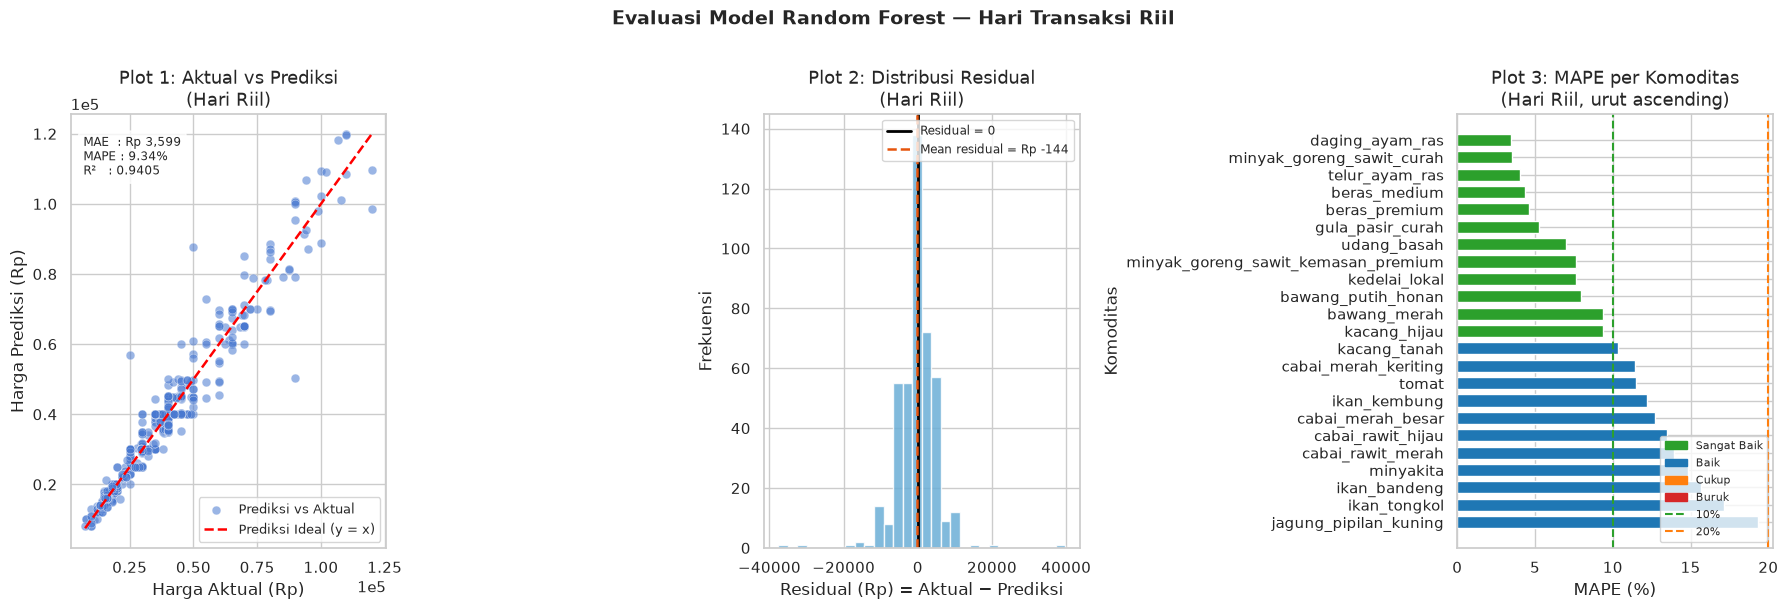


✅ Visualisasi disimpan : c:\Users\Saputra Budiman\Documents\Tugas Kuliah Semester Genap 2025-2026\Sistem Informasi Manajemen\Skripsi - Pantau Pasar\SPK SIM\figures\bab4\gambar_4_evaluasi_model.png


In [9]:
# =============================================================================
# SEL 8 — Visualisasi BAB IV
# 3 plot dalam 1 figure:
#   Plot 1: Scatter Actual vs Predicted (df_real)
#   Plot 2: Histogram distribusi residual (df_real)
#   Plot 3: Horizontal bar chart MAPE per komoditas
# Simpan ke FIGURES_DIR/gambar_4_evaluasi_model.png @ 150 DPI
# =============================================================================

# Palet warna per kategori
WARNA_KAT = {
    "Sangat Baik" : "#2ca02c",   # hijau
    "Baik"        : "#1f77b4",   # biru
    "Cukup"       : "#ff7f0e",   # oranye
    "Buruk"       : "#d62728",   # merah
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Evaluasi Model Random Forest — Hari Transaksi Riil",
    fontsize=14, fontweight="bold", y=1.01
)

# ─────────────────────────────────────────────────────────────────────────────
# Plot 1: Scatter Actual vs Predicted (df_real saja)
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0]

ax1.scatter(
    y_true_real, y_pred_real,
    alpha=0.55, s=40, color="#4878d0", edgecolors="white", linewidths=0.4,
    label="Prediksi vs Aktual"
)

# Garis diagonal merah putus-putus (prediksi ideal: y_pred = y_actual)
lo = min(y_true_real.min(), y_pred_real.min())
hi = max(y_true_real.max(), y_pred_real.max())
ax1.plot([lo, hi], [lo, hi], color="red", linestyle="--", lw=1.8,
         label="Prediksi Ideal (y = x)")

ax1.set_title("Plot 1: Aktual vs Prediksi\n(Hari Riil)")
ax1.set_xlabel("Harga Aktual (Rp)")
ax1.set_ylabel("Harga Prediksi (Rp)")
ax1.legend(fontsize=9)
ax1.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))

# Anotasi metrik di sudut kiri atas
ax1.text(
    0.04, 0.95,
    f"MAE  : Rp {mae_r:,.0f}\nMAPE : {mape_r:.2f}%\nR²   : {r2_r:.4f}",
    transform=ax1.transAxes, fontsize=8.5, va="top",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8)
)

# ─────────────────────────────────────────────────────────────────────────────
# Plot 2: Histogram distribusi residual (df_real saja)
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[1]

residuals_real = df_real["residual"].values
mean_res = float(np.mean(residuals_real))

ax2.hist(
    residuals_real, bins=30,
    color="#6baed6", edgecolor="white", alpha=0.85
)

# Garis vertikal di 0 dan di mean residual
ax2.axvline(x=0,        color="black",  linestyle="-",  lw=2,   label="Residual = 0")
ax2.axvline(x=mean_res, color="#e6550d", linestyle="--", lw=1.8,
            label=f"Mean residual = Rp {mean_res:,.0f}")

ax2.set_title("Plot 2: Distribusi Residual\n(Hari Riil)")
ax2.set_xlabel("Residual (Rp) = Aktual − Prediksi")
ax2.set_ylabel("Frekuensi")
ax2.legend(fontsize=8.5)

# ─────────────────────────────────────────────────────────────────────────────
# Plot 3: Horizontal bar chart MAPE per komoditas (urut ascending)
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[2]

bar_colors = [WARNA_KAT[k] for k in df_per_kom["Kategori"]]
ax3.barh(
    df_per_kom["Komoditas"],
    df_per_kom["MAPE_Pct"],
    color=bar_colors, edgecolor="white", height=0.7
)

# Garis batas kategori
ax3.axvline(x=10, color="#2ca02c", linestyle="--", lw=1.5, label="10% (Sangat Baik)")
ax3.axvline(x=20, color="#ff7f0e", linestyle="--", lw=1.5, label="20% (Baik)")

ax3.set_title("Plot 3: MAPE per Komoditas\n(Hari Riil, urut ascending)")
ax3.set_xlabel("MAPE (%)")
ax3.set_ylabel("Komoditas")
ax3.invert_yaxis()   # MAPE terendah di atas

# Legend kategori
legend_patches = [
    mpatches.Patch(color=WARNA_KAT[k], label=k)
    for k in ["Sangat Baik", "Baik", "Cukup", "Buruk"]
]
ax3.legend(
    handles=legend_patches + [
        plt.Line2D([0], [0], color="#2ca02c", linestyle="--", lw=1.5, label="10%"),
        plt.Line2D([0], [0], color="#ff7f0e", linestyle="--", lw=1.5, label="20%"),
    ],
    fontsize=8, loc="lower right"
)

# ─────────────────────────────────────────────────────────────────────────────
# Simpan figure
# ─────────────────────────────────────────────────────────────────────────────
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "gambar_4_evaluasi_model.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Visualisasi disimpan : {os.path.abspath(fig_path)}")

## SEL 9 — Simpan Semua Hasil Evaluasi

In [10]:
# =============================================================================
# SEL 9 — Simpan semua artefak hasil evaluasi
# File yang disimpan:
#   evaluation_per_commodity.csv  → hasil per komoditas (SEL 6)
#   feature_importance.csv        → hasil feature importance (SEL 7)
#   evaluation_summary.json       → ringkasan dua layer + top-3 fitur
#                                   → OUTPUT UTAMA untuk penulisan BAB IV
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# 1. evaluation_per_commodity.csv
# ─────────────────────────────────────────────────────────────────────────────
comm_path = os.path.join(RESULTS_DIR, "evaluation_per_commodity.csv")
df_per_kom.to_csv(comm_path, index=True, index_label="Rank")
print(f"✅ Disimpan : {comm_path}")
print(f"   ({len(df_per_kom)} komoditas × {df_per_kom.shape[1]} kolom)")

# ─────────────────────────────────────────────────────────────────────────────
# 2. feature_importance.csv
# ─────────────────────────────────────────────────────────────────────────────
fi_path = os.path.join(RESULTS_DIR, "feature_importance.csv")
fi_df.to_csv(fi_path, index=False)
print(f"✅ Disimpan : {fi_path}")
print(f"   ({len(fi_df)} fitur)")

# ─────────────────────────────────────────────────────────────────────────────
# 3. evaluation_summary.json — OUTPUT UTAMA untuk penulisan BAB IV
# ─────────────────────────────────────────────────────────────────────────────

# Top-3 fitur berdasarkan importance
top3_fi = fi_df.head(3)[["Rank", "Fitur", "Kategori", "Pct", "Pct_Kum"]]
top3_fi_list = top3_fi.to_dict(orient="records")

# Ringkasan per kategori MAPE
kat_summary = {
    k: int(kat_count.get(k, 0))
    for k in ["Sangat Baik", "Baik", "Cukup", "Buruk"]
}

evaluation_summary = {
    # --- Informasi dataset test ---
    "test_set_info": {
        "n_total"         : int(n_total),
        "n_imputed_ffill" : int(n_imputed),
        "n_real_days"     : int(n_real),
        "pct_imputed"     : round(pct_imp,  2),
        "pct_real"        : round(pct_real, 2),
    },
    # --- Layer 1: Global ---
    "layer1_global": {
        "note"  : "~98% ffill — tidak representatif. Gunakan layer2_hari_riil.",
        "n_rows": int(n_total),
        "mae"   : round(mae_g,  2),
        "rmse"  : round(rmse_g, 2),
        "mape"  : round(mape_g, 4),
        "r2"    : round(r2_g,   6),
    },
    # --- Layer 2: Hari riil ---
    "layer2_hari_riil": {
        "note"            : "Evaluasi genuine — hanya 382 hari transaksi riil.",
        "n_rows"          : int(n_real),
        "model_rf": {
            "mae" : round(mae_r,  2),
            "rmse": round(rmse_r, 2),
            "mape": round(mape_r, 4),
            "r2"  : round(r2_r,   6),
        },
        "naive_baseline": {
            "description": "prediksi = Harga_Kemarin",
            "mae" : round(mae_n,  2),
            "rmse": round(rmse_n, 2),
            "mape": round(mape_n, 4),
        },
        "improvement_vs_naive": {
            "mae_pct" : round(imp_mae,  2),
            "rmse_pct": round(imp_rmse, 2),
            "mape_pct": round(imp_mape, 2),
        },
    },
    # --- Per komoditas ---
    "per_komoditas": {
        "n_komoditas_dievaluasi" : int(len(df_per_kom)),
        "n_komoditas_skip"       : int(len(skipped)),
        "min_rows_threshold"     : MIN_ROWS,
        "model_lebih_baik_dari_naive": int(n_lebih_baik),
        "ringkasan_kategori_mape": kat_summary,
    },
    # --- Feature importance top 3 ---
    "feature_importance_top3"   : top3_fi_list,
    "hipotesis_eda_terkonfirmasi": is_harga_kemarin_rank1,
}

summary_path = os.path.join(RESULTS_DIR, "evaluation_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_summary, f, indent=2, ensure_ascii=False)
print(f"✅ Disimpan : {summary_path}")

# ─────────────────────────────────────────────────────────────────────────────
# Ringkasan akhir
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 65)
print("SEMUA ARTEFAK EVALUASI BERHASIL DISIMPAN")
print("=" * 65)
print(f"  results/evaluation_per_commodity.csv   → evaluasi per komoditas")
print(f"  results/feature_importance.csv         → feature importance")
print(f"  results/evaluation_summary.json        → OUTPUT UTAMA BAB IV")
print(f"  figures/bab4/gambar_4_evaluasi_model.png → visualisasi 3-panel")
print("=" * 65)
print()
print("RANGKUMAN UNTUK BAB IV:")
print(f"  Layer 1 (global, termasuk ffill) → MAPE : {mape_g:.4f}%")
print(f"  Layer 2 (hari riil saja)         → MAPE : {mape_r:.4f}%")
print(f"  Naive baseline (hari riil)       → MAPE : {mape_n:.4f}%")
print(f"  Model lebih baik dari naive      : {n_lebih_baik}/{len(df_per_kom)} komoditas")
print(f"  Fitur terpenting (Rank #1)       : {rank1_fitur}")
print("=" * 65)

✅ Disimpan : ../results\evaluation_per_commodity.csv
   (23 komoditas × 8 kolom)
✅ Disimpan : ../results\feature_importance.csv
   (13 fitur)
✅ Disimpan : ../results\evaluation_summary.json

SEMUA ARTEFAK EVALUASI BERHASIL DISIMPAN
  results/evaluation_per_commodity.csv   → evaluasi per komoditas
  results/feature_importance.csv         → feature importance
  results/evaluation_summary.json        → OUTPUT UTAMA BAB IV
  figures/bab4/gambar_4_evaluasi_model.png → visualisasi 3-panel

RANGKUMAN UNTUK BAB IV:
  Layer 1 (global, termasuk ffill) → MAPE : 0.5583%
  Layer 2 (hari riil saja)         → MAPE : 9.3435%
  Naive baseline (hari riil)       → MAPE : 9.4599%
  Model lebih baik dari naive      : 17/23 komoditas
  Fitur terpenting (Rank #1)       : Harga_Kemarin
